# Supermarket Sales Analysis - Data Analytics Project

**Goal:** Analyze supermarket sales data and find useful information about products, branches,
categories, customers, payment methods, and ratings.

**Dataset:** 500 simulated sales transactions (`data/supermarket_sales.csv`) with product, branch,
city, customer type, quantity, unit price, payment method, and rating.

**Notebook sections**
1. Load libraries and data
2. Data cleaning
3. Feature engineering (Sales = Quantity x Unit Price)
4. Business question analysis (with charts)
5. Business decisions & conclusion


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = "../data/supermarket_sales.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df_raw)}, Columns: {list(df_raw.columns)}")
df_raw.head()


Rows: 500, Columns: ['InvoiceID', 'Date', 'Branch', 'City', 'Category', 'Product', 'Unit Price', 'Quantity', 'CustomerType', 'PaymentMethod', 'Rating', 'Sales']


,InvoiceID,Date,Branch,City,Category,Product,Unit Price,Quantity,CustomerType,PaymentMethod,Rating,Sales
0,INV-1001,2024-04-02,C,Mumbai,Bakery,Croissant,119.36,9.0,Normal,Card,3.8,1074.24
1,INV-1002,2024-04-25,B,Delhi,Bakery,White Bread,140.85,8.0,Normal,Cash,3.4,1126.80
2,INV-1003,2024-03-21,B,Delhi,Beverages,Coffee Powder,121.07,9.0,Normal,UPI,4.8,1089.63
3,INV-1004,2024-01-28,C,Mumbai,Beverages,Coffee Powder,100.04,6.0,Normal,Card,3.7,600.24
4,INV-1005,2024-04-11,B,Delhi,Bakery,White Bread,48.68,5.0,Member,Cash,3.4,243.40


## 2. Data Cleaning

Check for missing values and inconsistent text before doing any analysis.

In [2]:
df_raw.isna().sum()


InvoiceID        0
Date             0
Branch           0
City             0
Category         0
Product          0
Unit Price       1
Quantity         1
CustomerType     0
PaymentMethod    1
Rating           1
Sales            0
dtype: int64

In [3]:
df = df_raw.copy()

# Normalize text columns (strip whitespace, fix casing)
for col in ["Branch", "City", "Category", "Product", "CustomerType", "PaymentMethod"]:
    df[col] = df[col].astype(str).str.strip()
df["Branch"] = df["Branch"].str.upper()
df["CustomerType"] = df["CustomerType"].str.title()
df["PaymentMethod"] = df["PaymentMethod"].replace({"None": None, "nan": None})

# Fill numeric gaps with the column median
for col in ["Unit Price", "Quantity", "Rating"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Drop rows still missing a payment method (needed for Q4)
df = df.dropna(subset=["PaymentMethod"]).reset_index(drop=True)
df["Date"] = pd.to_datetime(df["Date"])

print(f"Rows after cleaning: {len(df)}")
df.isna().sum()


Rows after cleaning: 499


InvoiceID        0
Date             0
Branch           0
City             0
Category         0
Product          0
Unit Price       0
Quantity         0
CustomerType     0
PaymentMethod    0
Rating           0
Sales            0
dtype: int64

## 3. Feature Engineering

Recalculate `Sales = Quantity x Unit Price` for every row, per the project methodology.

In [4]:
df["Sales"] = (df["Quantity"] * df["Unit Price"]).round(2)
df[["Product", "Branch", "Quantity", "Unit Price", "Sales"]].head()


,Product,Branch,Quantity,Unit Price,Sales
0,Croissant,C,9.0,119.36,1074.24
1,White Bread,B,8.0,140.85,1126.80
2,Coffee Powder,B,9.0,121.07,1089.63
3,Coffee Powder,C,6.0,100.04,600.24
4,White Bread,B,5.0,48.68,243.40


## 4. Business Questions

### Q1. Which product generates the highest sales?

Top product: Cheese -> Rs. 25,933.78


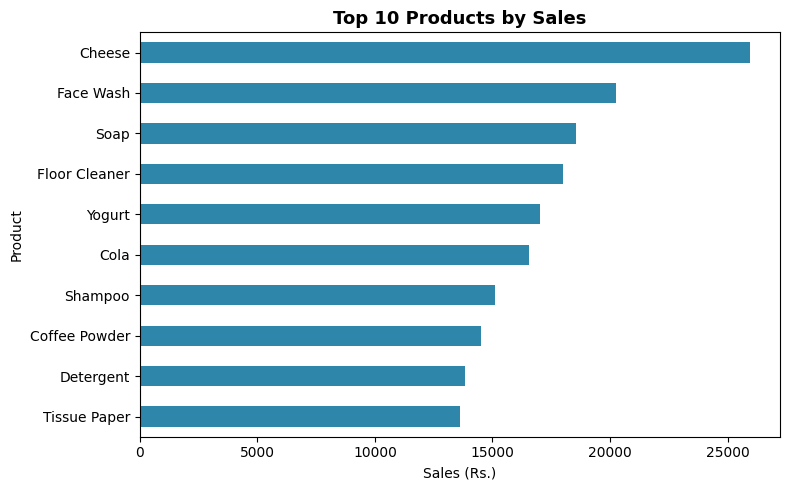

In [5]:
by_product = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
top_product, top_product_sales = by_product.index[0], by_product.iloc[0]
print(f"Top product: {top_product} -> Rs. {top_product_sales:,.2f}")

by_product.head(10).sort_values().plot(kind="barh", color="#2E86AB", figsize=(8, 5))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (Rs.)")
plt.tight_layout()
plt.show()


### Q2. Which branch performs best?

Branch  City  
C       Mumbai    155313.68
B       Delhi     111742.57
A       Kanpur     95099.24
Name: Sales, dtype: float64


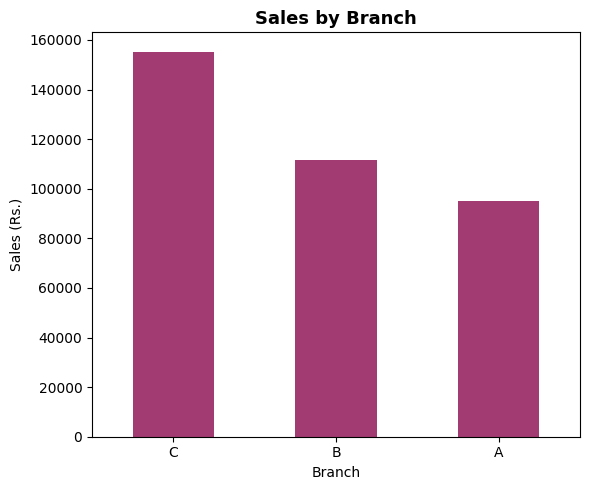

In [6]:
by_branch = df.groupby(["Branch", "City"])["Sales"].sum().sort_values(ascending=False)
print(by_branch)

df.groupby("Branch")["Sales"].sum().sort_values(ascending=False).plot(
    kind="bar", color="#A23B72", figsize=(6, 5))
plt.title("Sales by Branch")
plt.ylabel("Sales (Rs.)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q3. Which category sells the most?

Category
Beverages              87038.49
Personal Care          66013.71
Dairy                  58809.70
Household              56849.80
Snacks                 32663.60
Fruits & Vegetables    32293.18
Bakery                 28487.01
Name: Sales, dtype: float64


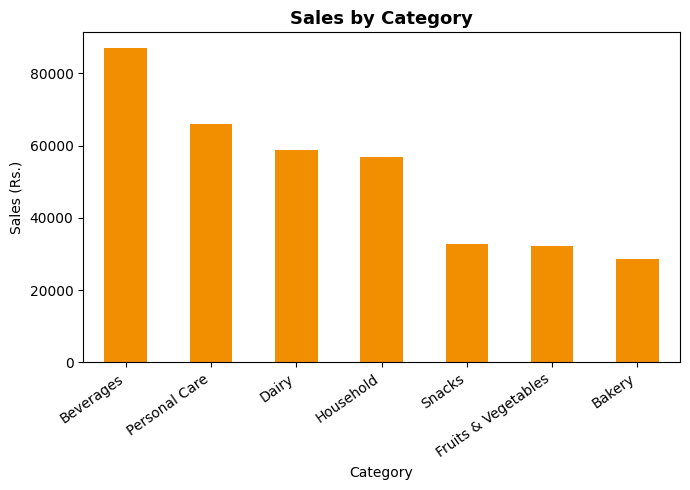

In [7]:
by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(by_category)

by_category.plot(kind="bar", color="#F18F01", figsize=(7, 5))
plt.title("Sales by Category")
plt.ylabel("Sales (Rs.)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Q4. What is the most popular payment method?

PaymentMethod
UPI     215
Cash    153
Card    131
Name: count, dtype: int64


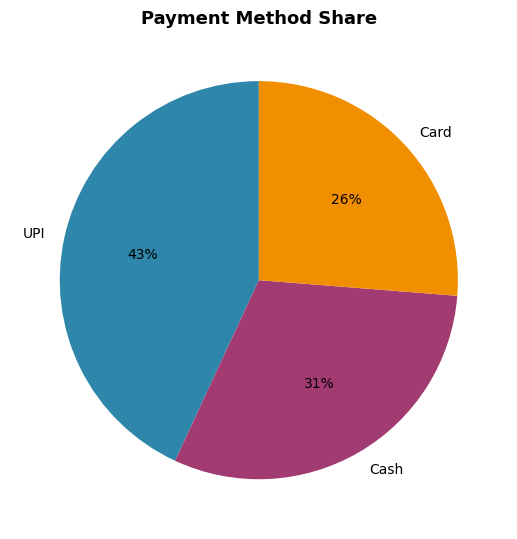

In [8]:
by_payment = df["PaymentMethod"].value_counts()
print(by_payment)

plt.figure(figsize=(5.5, 5.5))
plt.pie(by_payment.values, labels=by_payment.index, autopct="%1.0f%%",
        colors=["#2E86AB", "#A23B72", "#F18F01"], startangle=90)
plt.title("Payment Method Share")
plt.tight_layout()
plt.show()


### Q5. Do Members spend more than Normal customers?

CustomerType
Member    707.13
Normal    742.48
Name: Sales, dtype: float64


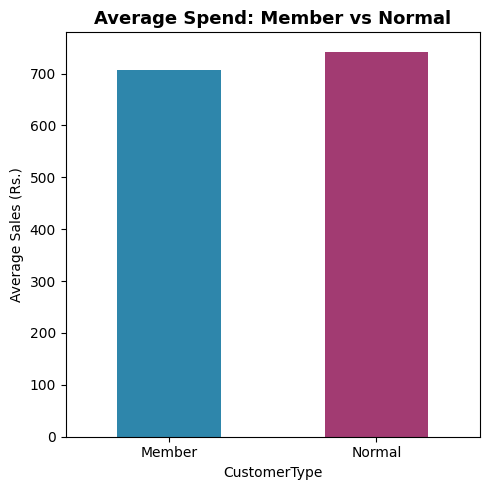

In [9]:
avg_by_customer = df.groupby("CustomerType")["Sales"].mean().round(2)
print(avg_by_customer)

avg_by_customer.plot(kind="bar", color=["#2E86AB", "#A23B72"], figsize=(5, 5))
plt.title("Average Spend: Member vs Normal")
plt.ylabel("Average Sales (Rs.)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Q6. What is the average customer rating?

Average rating: 3.94 / 5


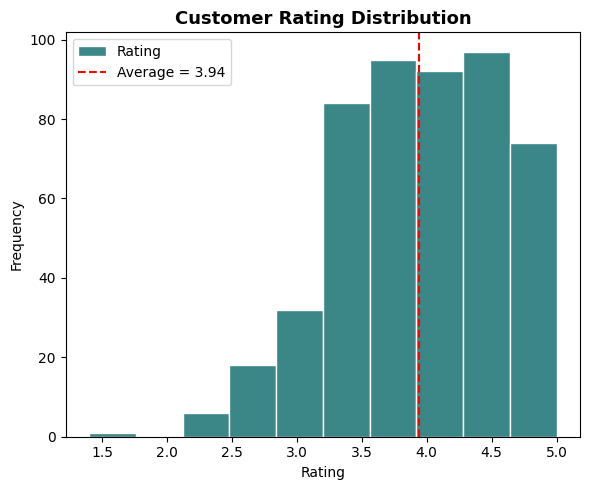

In [10]:
avg_rating = round(df["Rating"].mean(), 2)
print(f"Average rating: {avg_rating} / 5")

df["Rating"].plot(kind="hist", bins=10, color="#3B8686", edgecolor="white", figsize=(6, 5))
plt.axvline(avg_rating, color="red", linestyle="--", label=f"Average = {avg_rating}")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Business Decisions

- Keep more stock of high-selling products (e.g. the top product identified above) and categories.
- Study the reasons for the best-performing branch's strong performance and try to replicate them elsewhere.
- Continue supporting and promoting the most popular payment method.
- Improve customer service in areas where ratings are lower, to lift the overall average rating.
- Use the member vs normal spending comparison to redesign membership offers so they actually pay off.

## 6. Conclusion

This notebook shows, end to end, how raw transaction-level sales data can be cleaned and converted
into simple, decision-ready insights: top products, best branches, leading categories, preferred
payment methods, customer-segment spending patterns, and satisfaction levels.
